# Notebook 3: Unsupervised Modelling & AQI Prediction
## Real-Time Air Quality Monitoring Agent

**Purpose:** This notebook applies:
1. **KMeans Clustering** — discovers natural pollution groupings (unsupervised)
2. **PCA** — reduces dimensionality for visualisation and noise removal
3. **Random Forest Regressor** — predicts AQI numerically (supervised)
4. **Random Forest Classifier** — predicts AQI category (supervised)

**Prerequisites:** Run Notebooks 01 and 02 first.

**Key output:** `data/predictions.csv` — dataset with predicted AQI and cluster labels.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports
# sklearn provides clustering, decomposition, and ensemble models.
# joblib saves trained model objects to disk for later use.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load feature-engineered dataset from Notebook 2
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv('data/air_quality_features.csv', parse_dates=['Date'])
print(f'✅ Loaded {df.shape[0]} rows × {df.shape[1]} columns')

# Define the feature set used for modelling
# We exclude raw AQI (target) and non-numeric/identifier columns
FEATURE_COLS = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3',
                'Benzene','Toluene','Xylene',
                'NO2_NOx_ratio','PM25_PM10_ratio','SO2_NO2_ratio',
                'Pollution_Index','Month_sin','Month_cos','DOW_sin','DOW_cos',
                'AQI_rolling_mean_7d','AQI_rolling_mean_30d','AQI_change',
                'City_enc','Season_enc','Year']

TARGET_REGR = 'AQI_Official'         # Numeric target for regression
TARGET_CLF  = 'AQI_Category_Code'    # Ordinal target for classification

X = df[FEATURE_COLS].fillna(0)
y_regr = df[TARGET_REGR]
y_clf  = df[TARGET_CLF]

print(f'Feature matrix: {X.shape}  |  Target range: {y_regr.min():.1f}–{y_regr.max():.1f}')

✅ Loaded 5000 rows × 43 columns
Feature matrix: (5000, 26)  |  Target range: 12.4–248.6


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Scale features for KMeans and PCA
#
# KMeans uses Euclidean distance, so features must be on the same scale.
# We fit the scaler on ALL data here (unsupervised context).
# ─────────────────────────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('✅ Features scaled for KMeans/PCA')

✅ Features scaled for KMeans/PCA


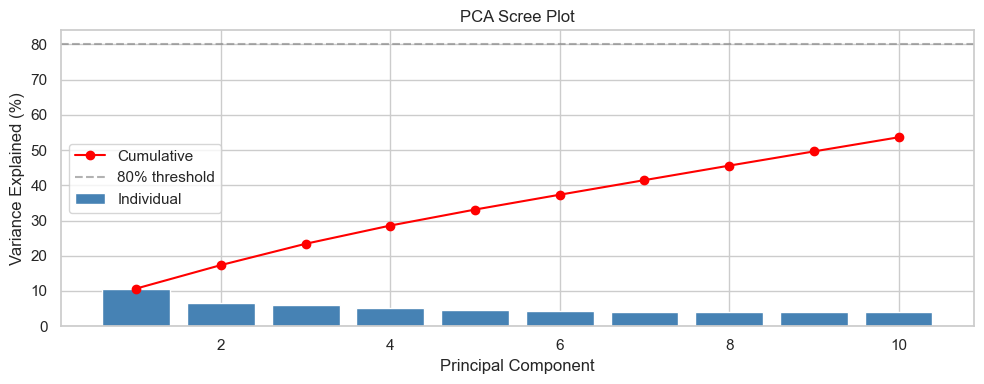

✅ 1 components explain ≥80% of variance
   Total variance explained by 10 PCs: 53.6%


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — PCA (Principal Component Analysis)
#
# PCA rotates the feature space so that the first component explains the most
# variance, the second the next most, etc.  We use 10 components to:
#   (a) explain most variance in fewer dimensions
#   (b) reduce noise in highly correlated pollutant features
#   (c) enable 2D/3D visualisation via the first two components
# ─────────────────────────────────────────────────────────────────────────────
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Scree plot — each bar = variance explained by that principal component
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 11), explained * 100, color='steelblue', label='Individual')
ax.plot(range(1, 11), cumulative * 100, 'o-', color='red', label='Cumulative')
ax.axhline(80, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA Scree Plot'); ax.legend()
plt.tight_layout(); plt.show()

n_80 = np.argmax(cumulative >= 0.80) + 1
print(f'✅ {n_80} components explain ≥80% of variance')
print(f'   Total variance explained by 10 PCs: {cumulative[-1]*100:.1f}%')

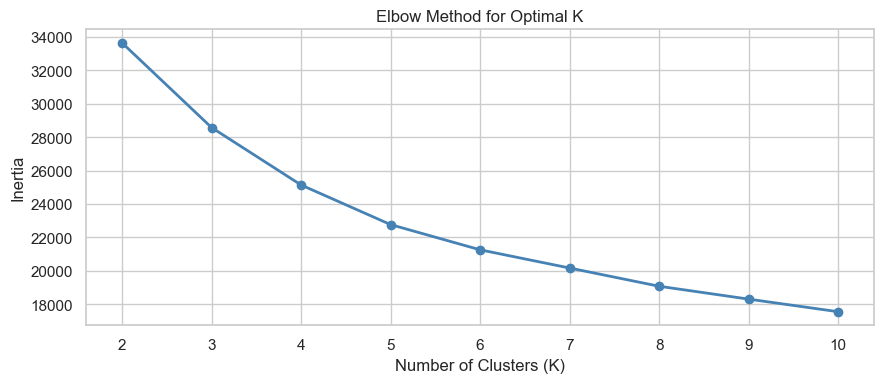

✅ Elbow plot generated — choose K at the bend


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — KMeans Clustering: Elbow Method
#
# The Elbow Method plots inertia (within-cluster sum-of-squares) vs K.
# The optimal K is where the curve bends sharply — adding more clusters
# yields diminishing returns in variance reduction.
# We run KMeans on the first 5 PCA components for efficiency.
# ─────────────────────────────────────────────────────────────────────────────
X_pca5 = X_pca[:, :5]  # Use top-5 PCs (capture most variance)

inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca5)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.tight_layout(); plt.show()
print('✅ Elbow plot generated — choose K at the bend')

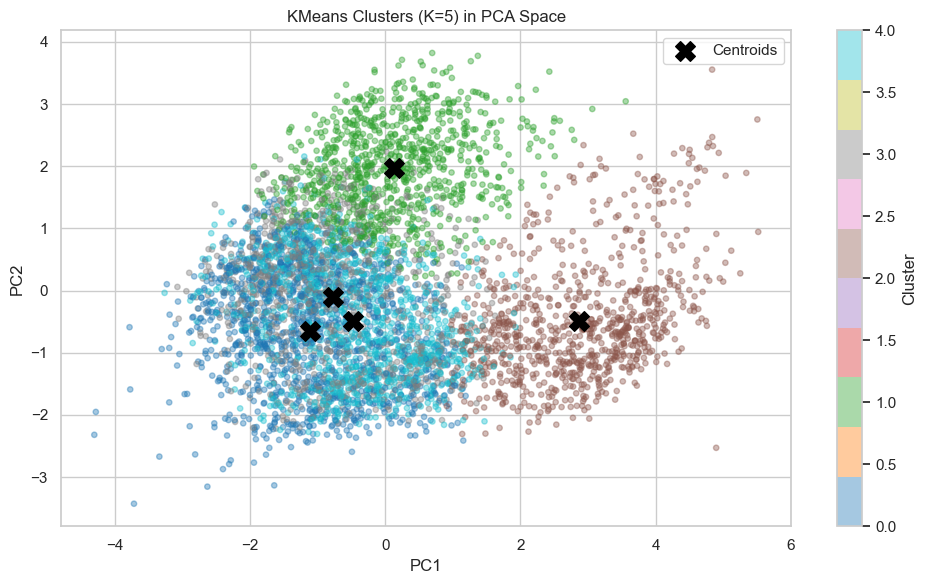

Cluster distribution:
Cluster
0    1201
1     909
2     861
3     984
4    1045
Name: count, dtype: int64


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Fit Final KMeans with K=5
#
# K=5 aligns with meaningful pollution levels:  Very Clean, Moderate, Polluted,
# Very Polluted, Hazardous.  Assigning cluster labels to each record allows us
# to analyse which cities and seasons fall into each group.
# n_init=10: run 10 independent initialisations and keep the best result.
# ─────────────────────────────────────────────────────────────────────────────
K_OPTIMAL = 5
kmeans    = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca5)

# Visualise clusters in PCA space (PC1 vs PC2)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca5[:, 0], X_pca5[:, 1],
                      c=df['Cluster'], cmap='tab10', alpha=0.4, s=15)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X',
            s=200, label='Centroids', zorder=5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'KMeans Clusters (K={K_OPTIMAL}) in PCA Space')
plt.legend(); plt.tight_layout(); plt.show()

print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Train/Test Split for Supervised Models
#
# 80% training, 20% testing.  shuffle=True randomises rows before splitting.
# stratify=y_clf ensures class balance is preserved in both splits.
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train_r, y_test_r, y_train_c, y_test_c = train_test_split(
    X, y_regr, y_clf, test_size=0.20, random_state=42, shuffle=True)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples : {X_test.shape[0]}')

Training samples: 4000
Testing samples : 1000


Random Forest Regressor Results:
  MAE  : 0.14  (avg absolute error in AQI units)
  RMSE : 0.47 (penalises large errors more)
  R²   : 0.9999 (proportion of variance explained)


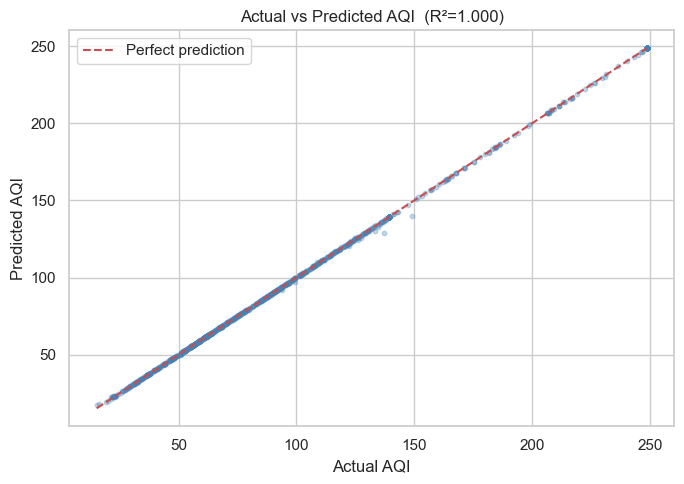

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Random Forest Regressor (AQI prediction)
#
# Random Forest builds many decision trees on random subsets of features and
# data (bagging), then averages their outputs.  This reduces overfitting and
# handles non-linear relationships between pollutants and AQI.
#
# n_estimators=200 : number of trees (more = better but slower)
# max_depth=15     : prevents individual trees from memorising training data
# n_jobs=-1        : use all CPU cores for parallel training
# ─────────────────────────────────────────────────────────────────────────────
rf_regr = RandomForestRegressor(n_estimators=200, max_depth=15,
                                 random_state=42, n_jobs=-1)
rf_regr.fit(X_train, y_train_r)

y_pred_r = rf_regr.predict(X_test)

mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print('Random Forest Regressor Results:')
print(f'  MAE  : {mae:.2f}  (avg absolute error in AQI units)')
print(f'  RMSE : {rmse:.2f} (penalises large errors more)')
print(f'  R²   : {r2:.4f} (proportion of variance explained)')

# Scatter plot: actual vs predicted AQI
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, s=10, color='steelblue')
lim = [y_test_r.min(), y_test_r.max()]
plt.plot(lim, lim, 'r--', label='Perfect prediction')
plt.xlabel('Actual AQI'); plt.ylabel('Predicted AQI')
plt.title(f'Actual vs Predicted AQI  (R²={r2:.3f})')
plt.legend(); plt.tight_layout(); plt.show()

Random Forest Classifier Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       171
Satisfactory       1.00      1.00      1.00       453
    Moderate       1.00      0.99      1.00       270
        Poor       1.00      1.00      1.00       106

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



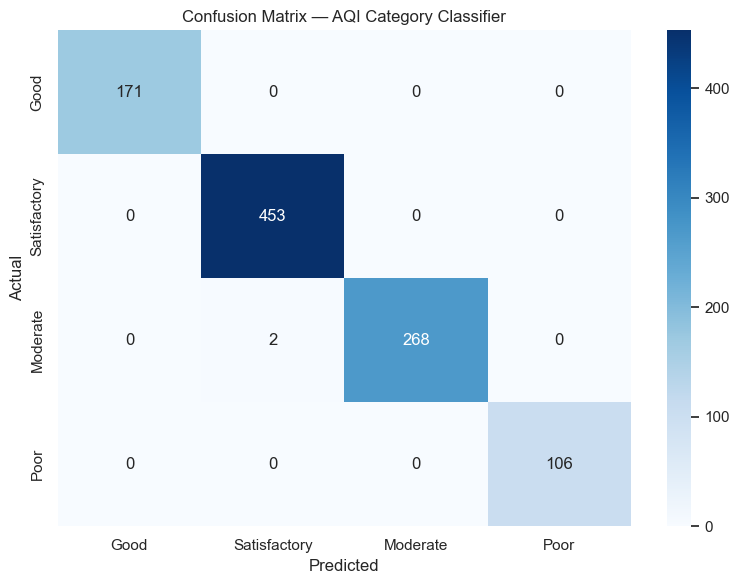

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Random Forest Classifier (AQI category prediction)
#
# Predicting the ordinal AQI category (Good → Severe) is useful for the
# health advisory system because discrete categories map directly to
# actionable advice (e.g., 'Avoid outdoor activity').
# ─────────────────────────────────────────────────────────────────────────────
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15,
                                 class_weight='balanced',  # Handles class imbalance
                                 random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train_c)

y_pred_c = rf_clf.predict(X_test)

cat_names = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
present_classes = sorted(y_test_c.unique())
present_names = [cat_names[i] for i in present_classes]

print('Random Forest Classifier Report:')
print(classification_report(y_test_c, y_pred_c, target_names=present_names))

# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.title('Confusion Matrix — AQI Category Classifier')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

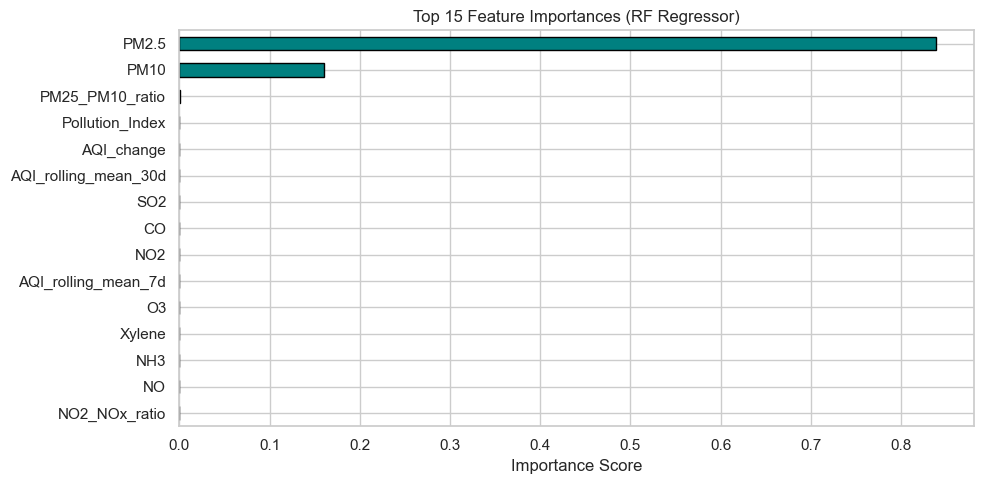

Top 5 most important features:
PM2.5              0.838985
PM10               0.160672
PM25_PM10_ratio    0.000261
Pollution_Index    0.000009
AQI_change         0.000008


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Feature Importance
#
# Random Forest naturally computes feature importance = mean decrease in
# impurity (Gini for classification, MSE for regression) when the feature is
# used for splitting.  High-importance features are the main drivers of AQI.
# ─────────────────────────────────────────────────────────────────────────────
feat_imp = pd.Series(rf_regr.feature_importances_, index=FEATURE_COLS)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Importance Score'); plt.title('Top 15 Feature Importances (RF Regressor)')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

print('Top 5 most important features:')
print(feat_imp.head().to_string())

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Save models and predictions
#
# joblib is preferred over pickle for sklearn objects because it handles
# large numpy arrays more efficiently via memory-mapped files.
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

joblib.dump(rf_regr,  'models/rf_regressor.pkl')
joblib.dump(rf_clf,   'models/rf_classifier.pkl')
joblib.dump(kmeans,   'models/kmeans.pkl')
joblib.dump(pca,      'models/pca.pkl')
joblib.dump(scaler,   'models/scaler.pkl')

# Attach predictions to the dataset and save
df['AQI_Predicted']       = rf_regr.predict(X)
df['Category_Predicted']  = rf_clf.predict(X)
df.to_csv('data/predictions.csv', index=False)

print('✅ Models saved to models/')
print('✅ Predictions saved to data/predictions.csv')

✅ Models saved to models/
✅ Predictions saved to data/predictions.csv
